In [1]:
#import and formatting
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import kruskal, mannwhitneyu
from itertools import combinations
from statsmodels.stats.multitest import multipletests
import numpy as np

plt.rcParams['pdf.fonttype'] = 42

file_path = 'Source_Data_CXCL12_placenta.xlsx'
sheet_data = pd.read_excel(file_path, sheet_name='Fig_2B')

# Drop empty columns
sheet_data.dropna(axis=1, how='all', inplace=True)

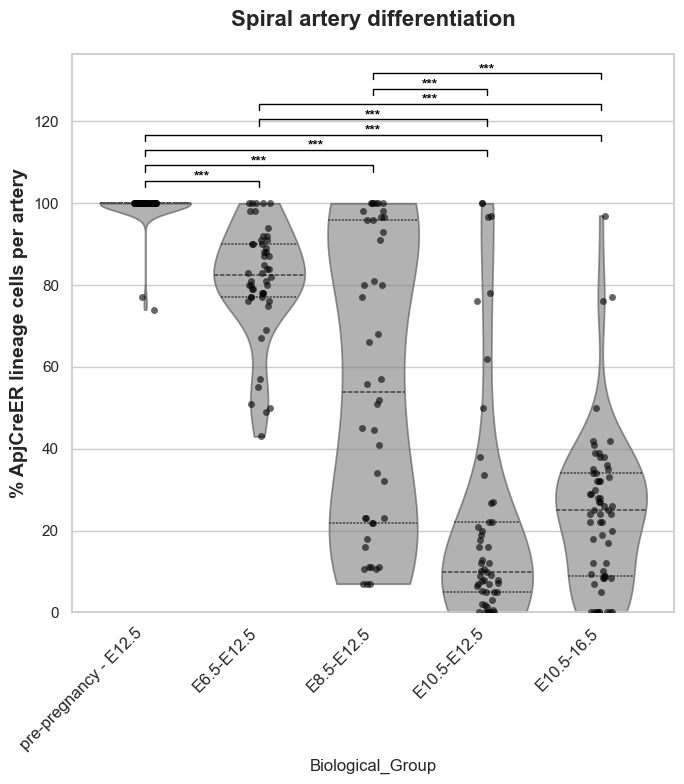

In [2]:
data_for_plot = []

for col in sheet_data.columns:
    if '(' in col:
        bio_group = col.split('(')[0].strip()
    else:
        bio_group = col.strip()
    
    values = sheet_data[col].dropna()
    
    for value in values:
        data_for_plot.append({
            'Biological_Group': bio_group,
            'Percentage': value
        })

plot_df = pd.DataFrame(data_for_plot)
bio_groups = plot_df['Biological_Group'].unique()

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(7, 8))

sns.violinplot(
    data=plot_df, 
    x='Biological_Group', 
    y='Percentage',
    order=bio_groups,
    color='#808080', 
    inner='quartile', 
    alpha=0.6,
    width=0.8,
    density_norm='width',
    cut=0,                
    ax=ax
)

sns.stripplot(
    data=plot_df, 
    x='Biological_Group', 
    y='Percentage',
    order=bio_groups,
    color='black', 
    alpha=0.6, 
    size=5, 
    jitter=True, 
    zorder=3,
    ax=ax
)

group_data = [plot_df[plot_df['Biological_Group'] == bg]['Percentage'].values for bg in bio_groups]

if len(group_data) > 1:
    kw_stat, kw_p = kruskal(*group_data)

pairs = list(combinations(bio_groups, 2))
p_values = []

for g1, g2 in pairs:
    data1 = plot_df[plot_df['Biological_Group'] == g1]['Percentage']
    data2 = plot_df[plot_df['Biological_Group'] == g2]['Percentage']
    stat, p = mannwhitneyu(data1, data2, alternative='two-sided')
    p_values.append(p)

reject, pvals_corrected, _, _ = multipletests(p_values, alpha=0.05, method='bonferroni')

y_max = plot_df['Percentage'].max()
y_step = y_max * 0.015       
text_offset = y_max * 0.01   
current_y = y_max + (y_max * 0.04) 

for i, (g1, g2) in enumerate(pairs):
    if reject[i]: 
        x1 = list(bio_groups).index(g1)
        x2 = list(bio_groups).index(g2)
        
        p_val = pvals_corrected[i]
        if p_val < 0.001:
            sig_symbol = '***'
        elif p_val < 0.01:
            sig_symbol = '**'
        else:
            sig_symbol = '*'
            
        ax.plot([x1, x1, x2, x2], 
                [current_y, current_y + y_step, current_y + y_step, current_y], 
                lw=1, c='black')
        
        ax.text((x1 + x2) / 2, current_y + y_step + text_offset, sig_symbol, 
                ha='center', va='center', color='black', fontsize=10, fontweight='bold')
        
        current_y += y_step * 2.5 


ax.set_ylabel('% ApjCreER lineage cells per artery', fontsize=14, fontweight='bold')
ax.set_title('Spiral artery differentiation', fontsize=16, fontweight='bold', pad=20) 
ax.set_xticks(range(len(bio_groups)))
ax.set_xticklabels(bio_groups, rotation=45, ha='right', fontsize=12)
ax.set_ylim(0, current_y + y_step + text_offset)

plt.tight_layout()
plt.show()